In [1]:
import numpy as np
import pandas as pd
# import torch
# from torch import nn
# from torch.autograd import Variable

In [2]:
from scipy.stats import norm
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import make_blobs

# cell population size

In [ ]:
N0 = 3e6

def pop_size(t, N0=N0, L=1.3):
    """
    natural logistic function
    """
    k = 1.15
    b = 0.3 
    y = L / (1+ b*np.exp(-1*k* (t - 3)))
    Nt = N0 * y
    return Nt

In [ ]:
#light
[122, 182, 243]

# medium
[43, 154, 232]

# dark
[54, 118, 173]


In [ ]:
from matplotlib import cm

In [ ]:
colors = cm.Blues(np.arange(0.3,1,0.3))

In [ ]:
t_all = np.arange(0, 10, 0.01)
Nt_all  = pop_size(t_all)

In [ ]:
t_sampled = np.array([0, 3, 9])
Nt_sampled  = pop_size(t_sampled)

fig, ax = plt.subplots(1,1, figsize=(4, 1.5), dpi=700)

for i in range(len(t_sampled)):
    ax.bar(x=t_sampled[i], height=Nt_sampled[i], width=1.5, 
            linewidth=0.6, edgecolor='lightgray',
            color=colors[i])

ax.plot(t_all, Nt_all, '--', color='gray', linewidth=3)

for i in range(len(t_sampled)):
    ax.scatter(t_sampled[i], Nt_sampled[i], marker='o',
                linewidth=0.6, edgecolor='lightgray',
                 s=60, color=colors[i])

xticks=[0,3,6,9]
ax.set_xticks(xticks)
ax.set_xticklabels(['d%s'%(d+1) for d in xticks])

# ax.set_xlabel('real time')
ax.set_ylabel('cell population size')

sns.despine(ax=ax)

# cell density

In [4]:
## day1
X1, y = make_blobs(n_samples=1000,
                centers=2, 
                  cluster_std=3,
                  random_state=0)

X1 = np.multiply( X1 , np.array([[ 2/7 , 0.4]])  ) 
X1[:,0] += 3


## day4
seed= 190
X2, y = make_blobs(n_samples=2000,
                  centers=2, 
                  cluster_std=0.8,
                  random_state=seed)


X1_sub, y = make_blobs(n_samples=400,
                centers=2, 
                  cluster_std=3,
                  random_state=0)

X1_sub = np.multiply( X1_sub , np.array([[ 2/7 , 0.35]])  ) 
X1_sub[:,0] += 3
X1_sub[:,0] -= 0.5

X2 = np.concatenate([X2, X1_sub], axis=0)


## day10
seed= 187
X3, y = make_blobs(n_samples=3000,
                centers=2, 
                  cluster_std=1,
                  random_state=seed) 

X2_, y = make_blobs(n_samples=1400,
                centers=2, 
                  cluster_std=1,
                  random_state=190)


X3 = np.multiply( X3 , np.array([[ 0.8 , 1]])  ) 
X3[:,0] += 9
X3 = np.concatenate([X3, X2_, X1_sub], axis=0)


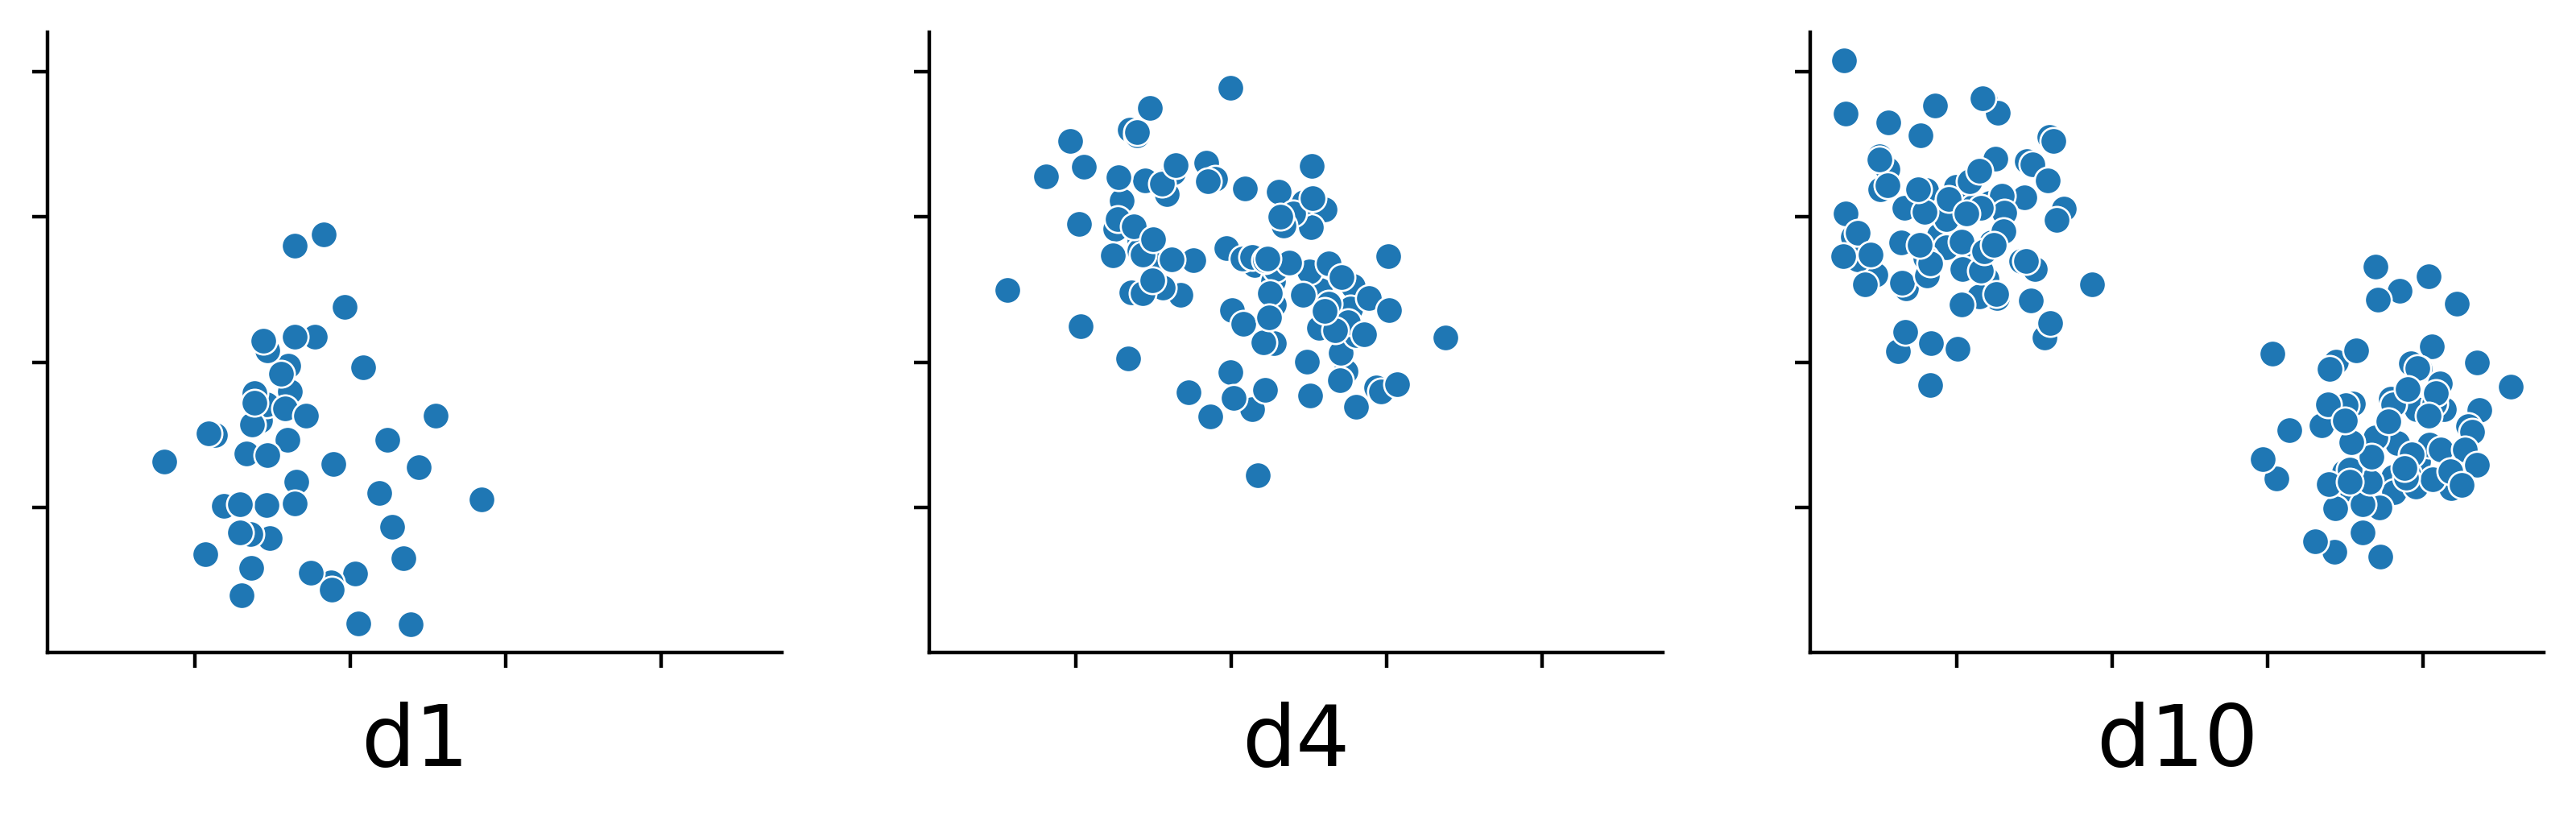

In [16]:
Xs = [X1, X2, X3]

days = ['d1', 'd4', 'd10']
fig, axs = plt.subplots(1,3, figsize=(10,2.5), dpi=400,gridspec_kw={'wspace':0.2}, sharex=True, sharey=True)

for i, X in enumerate(Xs):

    cbar = True if i == 2 else False
    
    n_cells = (i+1)*50
    g = sns.scatterplot(x=X[:n_cells,0], y=X[:n_cells,1], 
                         ax=axs[i], 
                    )
    sns.despine(ax=axs[i])
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].set_xlabel(days[i], fontsize=19)


In [17]:
fig.savefig('sampled_points.svg', transparent=True)

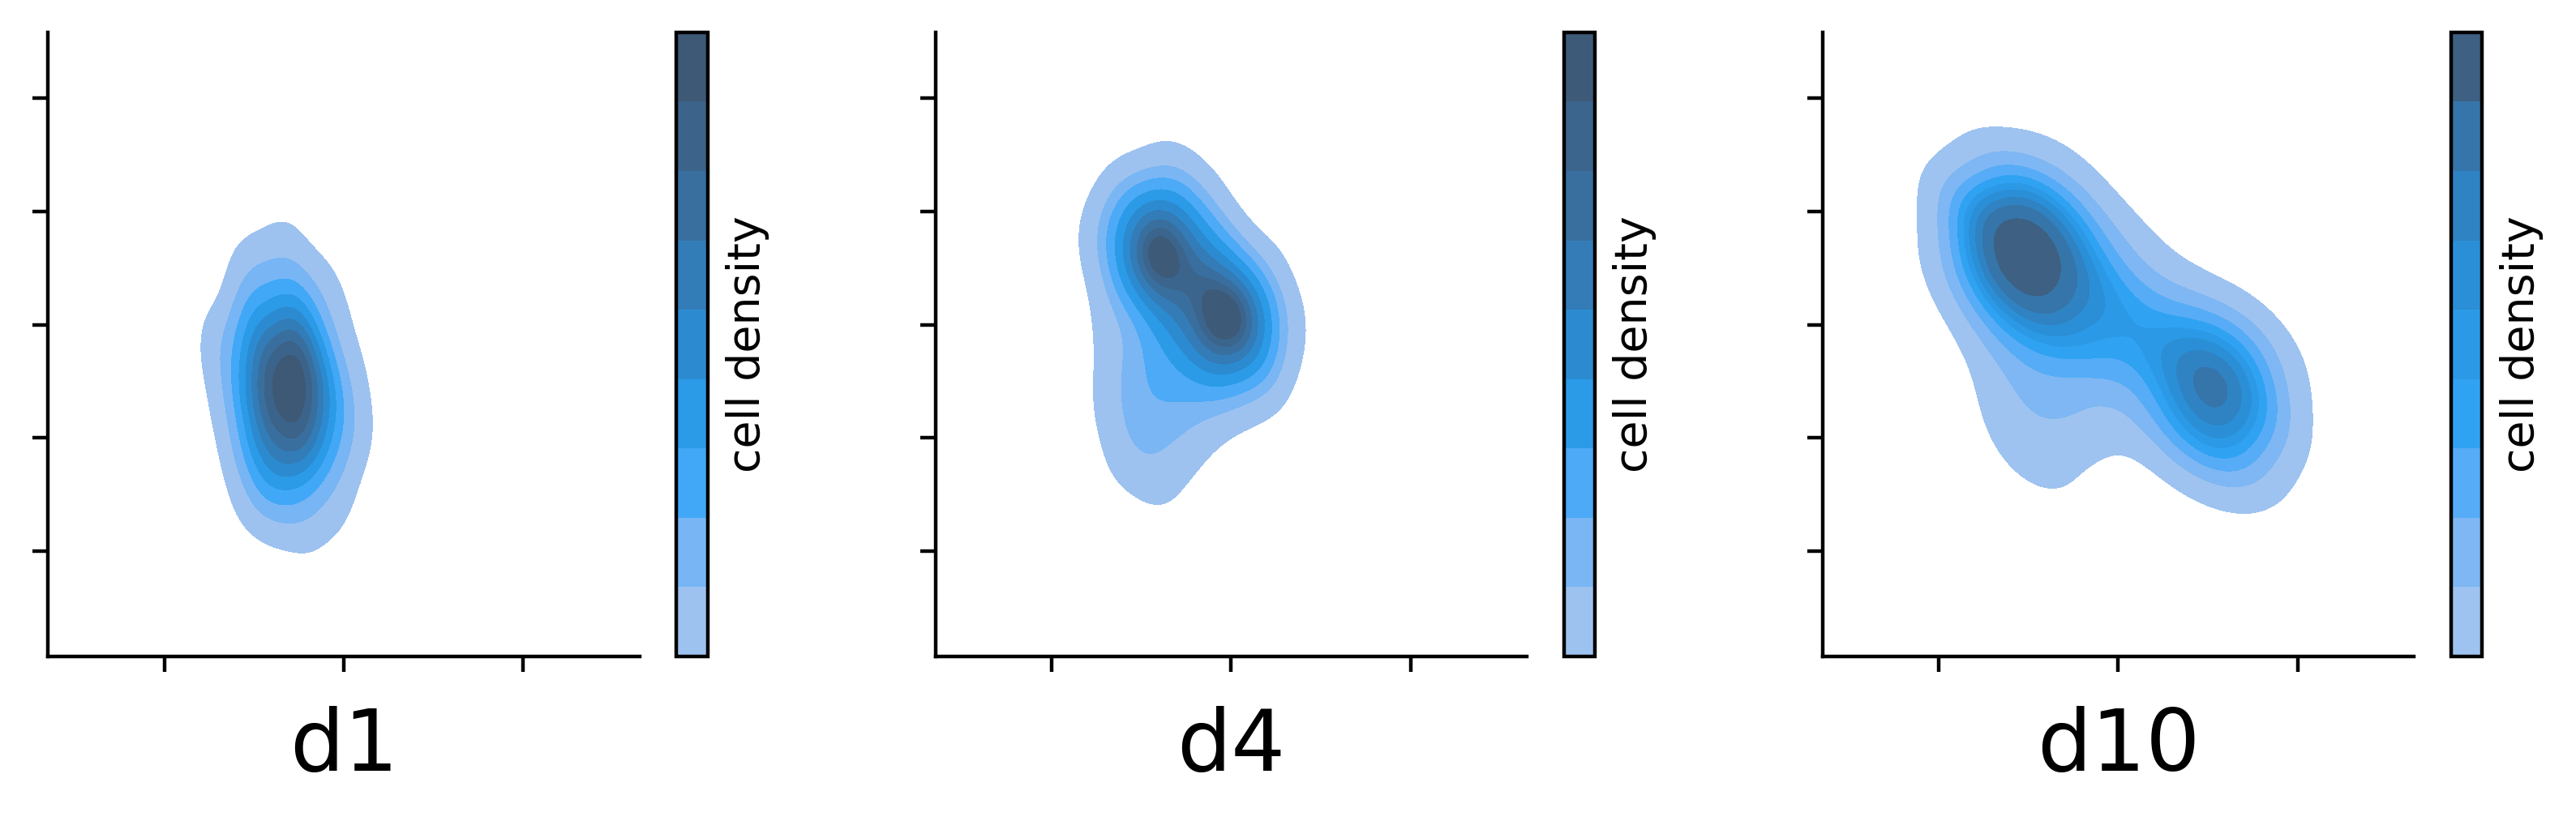

In [12]:
Xs = [X1, X2, X3]

days = ['d1', 'd4', 'd10']
fig, axs = plt.subplots(1,3, figsize=(10,2.5), dpi=400,gridspec_kw={'wspace':0.2}, sharex=True, sharey=True)

for i, X in enumerate(Xs):

    cbar = True if i == 2 else False
    g = sns.kdeplot(x=X[:,0], y=X[:,1], fill=True, cbar=True, 
                    bw_adjust=1.5, ax=axs[i], 
                    cbar_kws = {'label':'cell density', 
                                'ticks':[], }
                    )
    sns.despine(ax=axs[i])
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].set_xlabel(days[i], fontsize=19)


In [14]:
fig.savefig('sampled_density.svg', transparent=True)

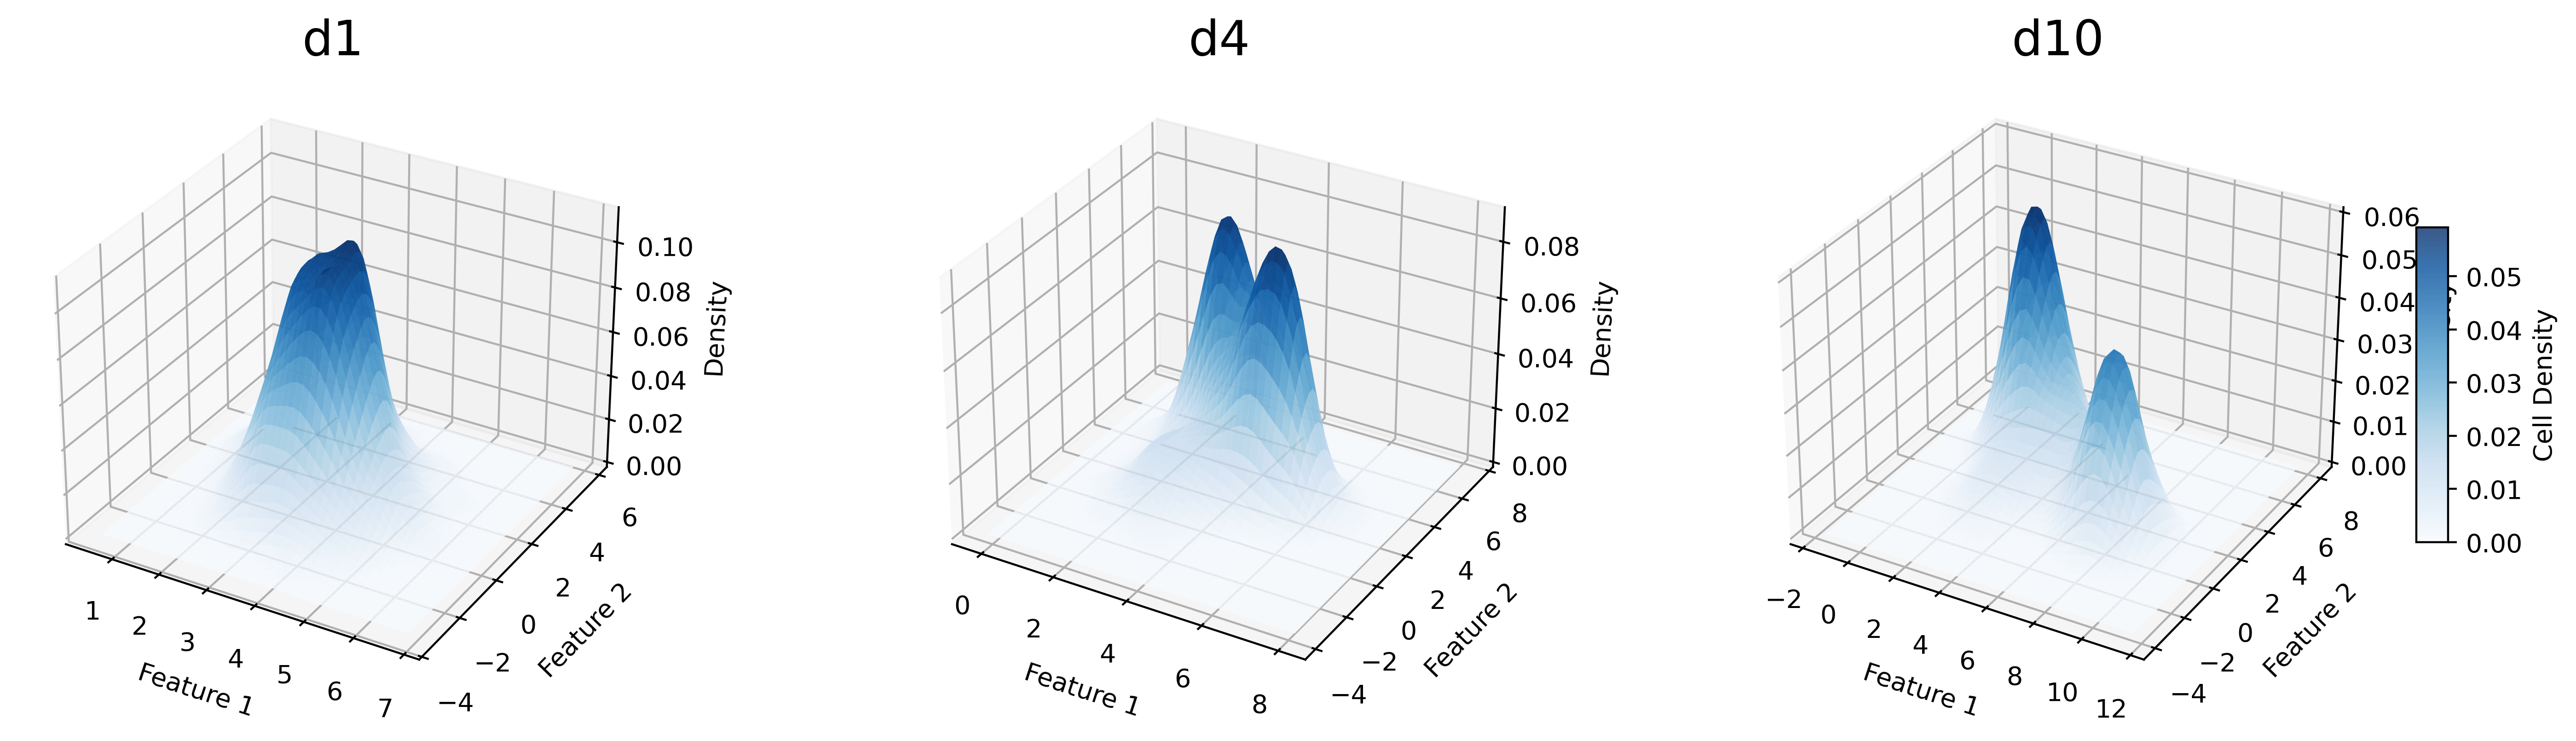

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Generate the 3D surface plot
Xs = [X1, X2, X3]
days = ['d1', 'd4', 'd10']

fig = plt.figure(figsize=(15, 4), dpi=400)
axs = [fig.add_subplot(1, 3, i+1, projection='3d') for i in range(3)]

for i, (X, ax) in enumerate(zip(Xs, axs)):
    # Calculate the Gaussian KDE
    kde = gaussian_kde(X.T)
    
    # Create a grid for evaluation
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Add margins to the grid
    margin = 0.1
    x_grid = np.linspace(x_min - x_range * margin, x_max + x_range * margin, 50)
    y_grid = np.linspace(y_min - y_range * margin, y_max + y_range * margin, 50)
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
    
    # Evaluate KDE on the grid
    positions = np.vstack([X_grid.ravel(), Y_grid.ravel()])
    Z = np.reshape(kde(positions).T, X_grid.shape)
    
    # Create 3D surface plot
    surf = ax.plot_surface(X_grid, Y_grid, Z, cmap='Blues', alpha=0.8, edgecolor='none')
    
    # Customize the plot
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Density')
    ax.set_title(days[i], fontsize=19)
    
    # Add color bar
    if i == 2:  # Only add colorbar to the last subplot
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Cell Density')

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('3d_surface_plot.png', transparent=True, bbox_inches='tight')

In [19]:
fig.savefig('3d_surface_plot.pdf', transparent=True, bbox_inches='tight')